# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>


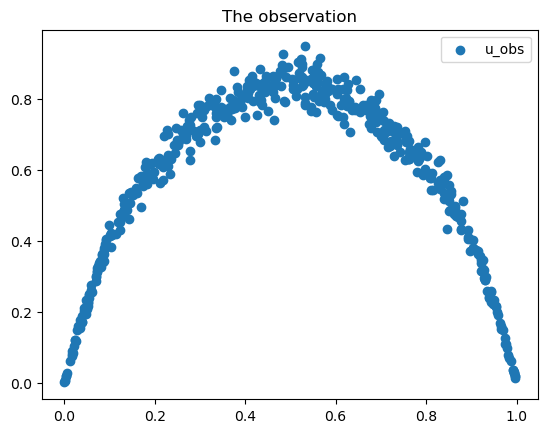

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#
with h5py.File('ProblemA_dataset.h5', 'r') as file:
    print(file.keys())
    #
    x_obs = np.array(file['x_obs']).reshape(-1,1)
    u_obs = np.array(file['u_obs']).reshape(-1,1)
    x_test = np.array(file['x_test']).reshape(-1,1)
    u_test = np.array(file['u_test']).reshape(-1,1)
    k_test = np.array(file["k_test"]).reshape(-1,1)
#
plt.figure()
plt.scatter(x_obs, u_obs, label='u_obs')
plt.title('The observation')
plt.legend()
plt.show()

In [2]:
#Convert To Tensor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

x_obs_t = torch.tensor(x_obs, dtype=torch.float32).to(device)
u_obs_t = torch.tensor(u_obs, dtype=torch.float32).to(device)
x_test_t = torch.tensor(x_test, dtype=torch.float32).to(device)
k_test_t = torch.tensor(k_test, dtype=torch.float32).to(device)
u_test_t = torch.tensor(u_test, dtype=torch.float32).to(device)

f_const = 9.81

In [3]:
# PINN Model
import torch.nn as nn
import torch.optim as optim
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        net = []
        for i in range(len(layers) - 1):
            net.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                net.append(nn.Tanh())
        self.net = nn.Sequential(*net)
        # last layer has 2 outputs u, k_raw
#Forward Pass
    def forward(self, x):
        y = self.net(x)
        u = y[:, 0:1]
        k_raw = y[:, 1:2]
        # Modulus of K so that k is positive and greater than 0 
        k = torch.nn.functional.softplus(k_raw) + 1e-3
        return u, k

layers = [1, 64, 64, 64, 64, 2]
model = PINN(layers).to(device)

In [4]:
#Residual loss

def pde_residual(x):
    x.requires_grad_(True)
    u, k = model(x)
    # du/dx
    du_dx = torch.autograd.grad(
        u, x, torch.ones_like(u), create_graph=True
    )[0]
    # k * du/dx
    k_du_dx = k * du_dx
    dk_du_dx_dx = torch.autograd.grad(
        k_du_dx, x, torch.ones_like(k_du_dx), create_graph=True
    )[0]
    # PDE: -(d/dx (k du/dx)) = f
    res = -dk_du_dx_dx - f_const
    return res

In [5]:
#Total Loss functon including boundary and function loss 

def loss_fn(x_obs_batch, u_obs_batch, x_col_batch):
    # data loss
    u_pred_obs, _ = model(x_obs_batch)
    L_data = torch.mean((u_pred_obs - u_obs_batch)**2)
    # PDE loss
    res = pde_residual(x_col_batch)
    L_pde = torch.mean(res**2)

    # boundary loss
    x0 = torch.zeros((1, 1), device=device)
    xL = torch.ones((1, 1), device=device)
    u0, _ = model(x0)
    uL, _ = model(xL)
    L_bc = u0.pow(2).mean() + uL.pow(2).mean()

    # weights , note that some comnination of weights were tried to get most accurate value of youngs modulus 
    lambda_data = 50.0
    lambda_pde = 5.0
    lambda_bc = 10.0

    L_total = lambda_data * L_data + lambda_pde * L_pde + lambda_bc * L_bc
    return L_total, L_data, L_pde, L_bc

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5000
batch_size_data = 128
batch_size_col = 128

N_obs = x_obs_t.shape[0]

errors_k = []
errors_u = []

In [6]:
num_epochs = 5000
batch_size_data = 128
batch_size_col = 128

N_obs = x_obs_t.shape[0]

errors_k = []
errors_u = []

def relative_L2_error(pred, true):
    num = torch.sum((pred - true)**2)
    den = torch.sum(true**2)
    return torch.sqrt(num / den).item()

In [7]:
#Training 

for epoch in range(1, num_epochs + 1):
    model.train()

    # sample data batch
    idx_data = np.random.choice(N_obs, batch_size_data, replace=False)
    x_obs_batch = x_obs_t[idx_data]
    u_obs_batch = u_obs_t[idx_data]
    x_col_batch = torch.rand((batch_size_col, 1), device=device)

    optimizer.zero_grad()
    L_total, L_data, L_pde, L_bc = loss_fn(x_obs_batch, u_obs_batch, x_col_batch)
    L_total.backward()
    optimizer.step()

    # compute test errors each epoch
    model.eval()
    with torch.no_grad():
        u_pred_test, k_pred_test = model(x_test_t)
        err_k = relative_L2_error(k_pred_test, k_test_t)
        err_u = relative_L2_error(u_pred_test, u_test_t)
        errors_k.append(err_k)
        errors_u.append(err_u)
        if epoch % 500 == 0:
              print(f"Epoch {epoch}: "
              f"Loss={L_total.item():.4e}, "
              f"Data={L_data.item():.4e}, "
              f"PDE={L_pde.item():.4e}, "
              f"BC={L_bc.item():.4e}, "
              f"Err_k={err_k:.4e}, Err_u={err_u:.4e}")

# final errors
print("Final relative L2 error k:", errors_k[-1])
print("Final relative L2 error u:", errors_u[-1])

Epoch 500: Loss=2.1192e-01, Data=1.8457e-03, PDE=1.4687e-02, BC=4.6206e-03, Err_k=2.2864e-01, Err_u=6.3393e-02
Epoch 1000: Loss=1.3683e-01, Data=2.4882e-03, PDE=6.9620e-04, BC=8.9399e-04, Err_k=2.3988e-01, Err_u=6.1289e-02
Epoch 1500: Loss=1.5708e-01, Data=3.0295e-03, PDE=7.9479e-04, BC=1.6326e-04, Err_k=2.3687e-01, Err_u=5.7917e-02
Epoch 2000: Loss=1.4081e-01, Data=2.6644e-03, PDE=5.7976e-04, BC=4.6857e-04, Err_k=2.3207e-01, Err_u=5.3376e-02
Epoch 2500: Loss=1.4955e-01, Data=2.0157e-03, PDE=3.9891e-03, BC=2.8817e-03, Err_k=2.2875e-01, Err_u=6.7318e-02
Epoch 3000: Loss=1.5403e-01, Data=2.0452e-03, PDE=2.7164e-03, BC=3.8187e-03, Err_k=2.2452e-01, Err_u=8.9082e-02
Epoch 3500: Loss=1.0419e-01, Data=1.8888e-03, PDE=1.0921e-03, BC=4.2836e-04, Err_k=2.1981e-01, Err_u=5.0788e-02
Epoch 4000: Loss=1.4248e-01, Data=2.1593e-03, PDE=6.3587e-03, BC=2.7241e-04, Err_k=2.1594e-01, Err_u=5.1626e-02
Epoch 4500: Loss=1.3643e-01, Data=2.0580e-03, PDE=5.9657e-03, BC=3.7078e-04, Err_k=2.1048e-01, Err_u=4.50

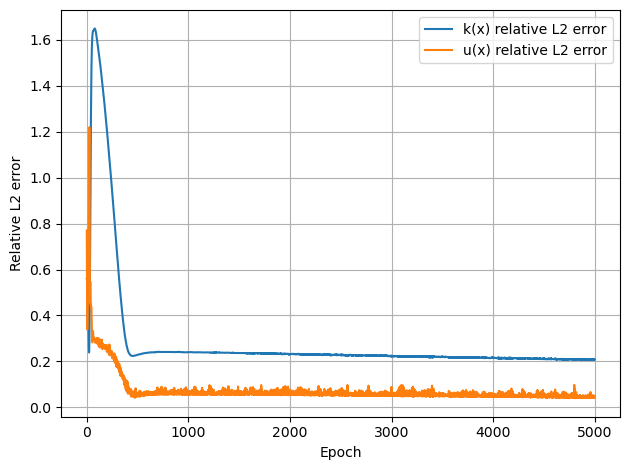

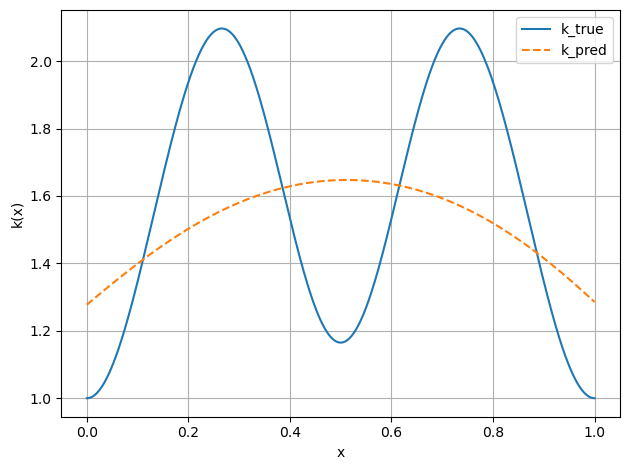

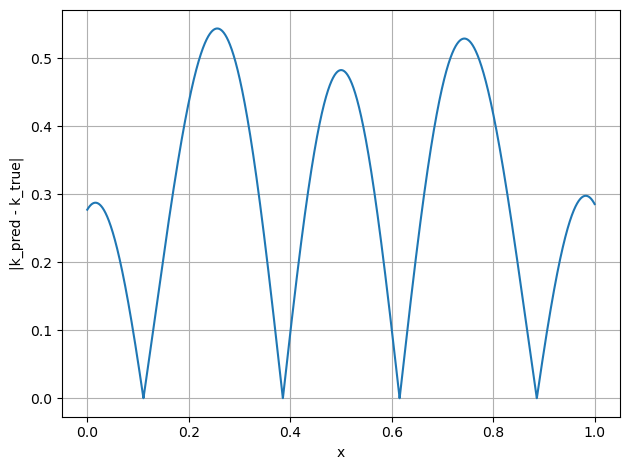

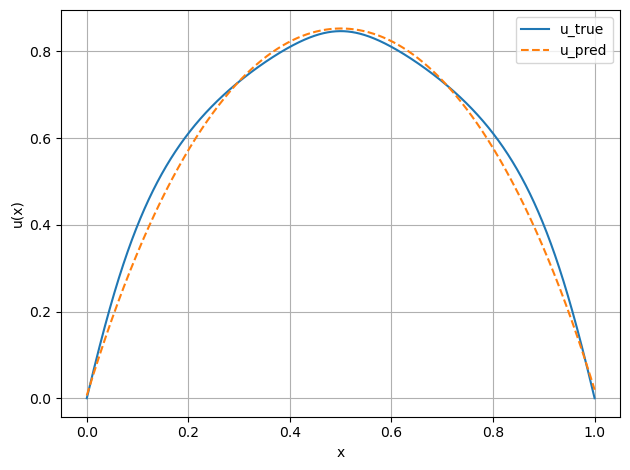

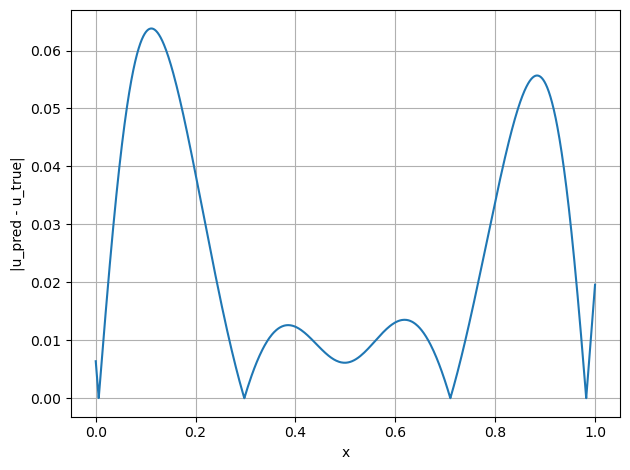

In [8]:
#Plots
#Error vs Epoch
plt.figure()
plt.plot(errors_k, label="k(x) relative L2 error")
plt.plot(errors_u, label="u(x) relative L2 error")
plt.xlabel("Epoch")
plt.ylabel("Relative L2 error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
model.eval()
with torch.no_grad():
    u_pred_test, k_pred_test = model(x_test_t)

x_test_np = x_test_t.cpu().numpy().flatten()
k_pred_np = k_pred_test.cpu().numpy().flatten()
k_true_np = k_test_t.cpu().numpy().flatten()
u_pred_np = u_pred_test.cpu().numpy().flatten()
u_true_np = u_test_t.cpu().numpy().flatten()

# k(x) comparison
plt.figure()
plt.plot(x_test_np, k_true_np, label="k_true")
plt.plot(x_test_np, k_pred_np, "--", label="k_pred")
plt.xlabel("x")
plt.ylabel("k(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure()
plt.plot(x_test_np, np.abs(k_pred_np - k_true_np))
plt.xlabel("x")
plt.ylabel("|k_pred - k_true|")
plt.grid(True)
plt.tight_layout()
plt.show()

# u(x) comparison
plt.figure()
plt.plot(x_test_np, u_true_np, label="u_true")
plt.plot(x_test_np, u_pred_np, "--", label="u_pred")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_test_np, np.abs(u_pred_np - u_true_np))
plt.xlabel("x")
plt.ylabel("|u_pred - u_true|")
plt.grid(True)
plt.tight_layout()
plt.show()